# 10 DenseNet121 cbam


In [1]:
EXPERIMENT_NAME = "densenet121_cbam_ce"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)
print("Max epochs:", MAX_EPOCHS)
print("Early stopping patience:", PATIENCE)
print("Monitor metric:", MONITOR_METRIC)


Experiment: densenet121_cbam_ce
Max epochs: 30
Early stopping patience: 7
Monitor metric: qwk


In [2]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\notebook
Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [3]:
import importlib
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.train_utils
import utils.dataset
import models.densenet_cbam

importlib.reload(utils.train_utils)
importlib.reload(utils.dataset)
importlib.reload(models.densenet_cbam)

from utils.dataset import get_dataloaders, print_dataset_info
from models.densenet_cbam import get_densenet121_cbam, count_trainable_parameters
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics, get_confusion_matrix




In [4]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121_cbam(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
    cbam_reduction_ratio=16,
    cbam_spatial_kernel_size=7,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")





Device: cuda
Trainable parameters: 7,090,151
Total parameters:     7,090,151


In [5]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [6]:
# loss and optimizer CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

## create densenet

In [7]:
from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 1.4263 | Train Acc: 0.3975 | Train Macro F1: 0.2376 | Train QWK: 0.2060
Val Loss:   1.2130 | Val Acc:   0.4658 | Val Macro F1: 0.2860 | Val QWK:   0.4290 | Val MAE:   0.9452
New best model found at epoch 1.
Best val qwk: 0.4290
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_cbam_ce.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.1535 | Train Acc: 0.9492 | Train Macro F1: 0.9444 | Train QWK: 0.9747
Val Loss:   0.8351 | Val Acc:   0.7329 | Val Macro F1: 0.7491 | Val QWK:   0.8724 | Val MAE:   0.3288
No improvement in val qwk. Patience: 6/7

Epoch 22/30
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.1439 | Train Acc: 0.9521 | Train Macro F1: 0.9478 | Train QWK: 0.9755
Val Loss:   0.7030 | Val Acc:   0.8082 | Val Macro F1: 0.8003 | Val QWK:   0.8981 | Val MAE:   0.2534
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 15
Best val qwk: 0.9373


In [8]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df.tail()

,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
17,18,0.176611,0.802167,15,2,0.942383,0.940125,0.942196,0.072266,0.973060,...,0.771819,0.770618,0.287671,0.888005,34,29,5,0.232877,0.198630,0.034247
18,19,0.145474,0.644015,15,3,0.945312,0.948474,0.945492,0.080078,0.963943,...,0.827854,0.832642,0.198630,0.925681,24,21,3,0.164384,0.143836,0.020548
19,20,0.142007,0.701692,15,4,0.957031,0.957967,0.956902,0.065430,0.969147,...,0.813322,0.808511,0.219178,0.922404,28,26,2,0.191781,0.178082,0.013699
20,21,0.153452,0.835097,15,5,0.949219,0.944381,0.949460,0.065430,0.974697,...,0.749127,0.736183,0.328767,0.872420,39,34,5,0.267123,0.232877,0.034247
21,22,0.143861,0.702964,15,6,0.952148,0.947801,0.952039,0.062500,0.975495,...,0.800274,0.803255,0.253425,0.898080,28,22,6,0.191781,0.150685,0.041096


## best epoch 

In [9]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                  15.000000
val_loss                0.682341
val_accuracy            0.801370
val_macro_f1            0.803147
val_weighted_f1         0.792623
val_mae                 0.212329
val_qwk                 0.937342
val_adjacent_errors    28.000000
val_distant_errors      1.000000
Name: 14, dtype: float64


## train model

In [12]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_cbam.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.1471 | Train Acc: 0.9482 | Train Macro F1: 0.9443 | Train QWK: 0.9703
Val Loss:   0.8864 | Val Acc:   0.7808 | Val Macro F1: 0.7873 | Val QWK:   0.9249 | Val MAE:   0.2397
New best model found at epoch 1.
Best val qwk: 0.9249
Saved best model to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ce_cbam.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.0935 | Train Acc: 0.9609 | Train Macro F1: 0.9574 | Train QWK: 0.9798
Val Loss:   0.8579 | Val Acc:   0.7945 | Val Macro F1: 0.7790 | Val QWK:   0.9237 | Val MAE:   0.2329
No improvement in val qwk. Patience: 2/7

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/64 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Train Loss: 0.1100 | Train Acc: 0.9502 | Train Macro F1: 0.9516 | Train QWK: 0.9687
Val Loss:   0.9280 | Val Acc:   0.7877 | Val Macro F1: 0.7923 | Val QWK:   0.9134 | Val MAE:   0.2534
No improvement in val qwk. Patience: 3/7


save history

In [13]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_cbam_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.147109,0.886432,0,0,0.948242,0.944264,0.948275,0.071289,0.970335,...,0.787274,0.777559,0.239726,0.924924,32,30,2,0.219178,0.205479,0.013699
1,2,0.101070,0.757431,1,0,0.960938,0.957131,0.960957,0.049805,0.981227,...,0.761212,0.773844,0.246575,0.920787,32,29,3,0.219178,0.198630,0.020548
2,3,0.104935,0.909344,1,1,0.961914,0.960857,0.961991,0.056641,0.973431,...,0.816649,0.806778,0.219178,0.924352,28,25,3,0.191781,0.171233,0.020548
3,4,0.093991,0.824665,1,2,0.964844,0.968143,0.964874,0.044922,0.982946,...,0.824928,0.823554,0.198630,0.930352,25,23,2,0.171233,0.157534,0.013699
4,5,0.100558,0.786208,4,0,0.966797,0.965073,0.966783,0.049805,0.977243,...,0.783377,0.784513,0.246575,0.913589,31,28,3,0.212329,0.191781,0.020548
5,6,0.093940,0.876652,4,1,0.972656,0.969891,0.972607,0.038086,0.984287,...,0.836633,0.823332,0.219178,0.910932,26,23,3,0.178082,0.157534,0.020548
6,7,0.076592,0.869420,4,2,0.972656,0.971097,0.972646,0.042969,0.979455,...,0.785579,0.789944,0.219178,0.935977,30,28,2,0.205479,0.191781,0.013699
7,8,0.106400,0.839232,7,0,0.958984,0.953951,0.959137,0.049805,0.982158,...,0.758885,0.758516,0.308219,0.882825,34,26,8,0.232877,0.178082,0.054795
8,9,0.093474,0.857867,7,1,0.960938,0.957390,0.961081,0.051758,0.979757,...,0.778976,0.784447,0.232877,0.923684,30,27,3,0.205479,0.184932,0.020548
9,10,0.110011,0.928050,7,2,0.950195,0.951605,0.950210,0.071289,0.968664,...,0.792306,0.777329,0.253425,0.913424,31,27,4,0.212329,0.184932,0.027397


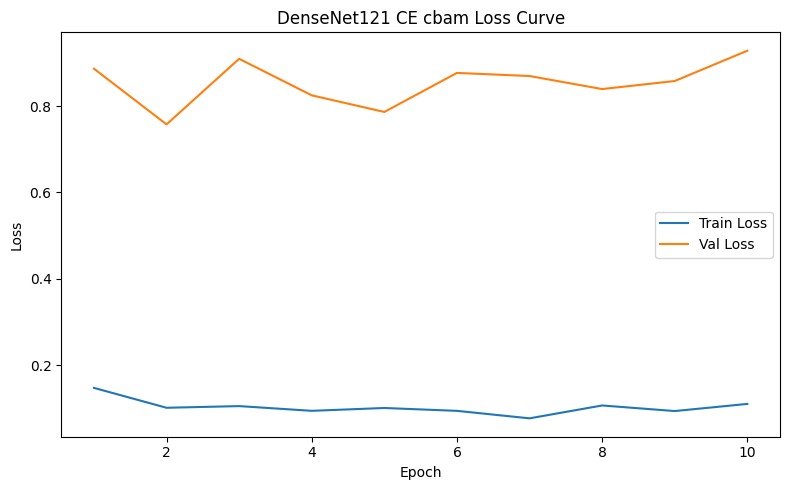

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_cbam_loss.png


In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE cbam Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_cbam_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [15]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.7945
macro_f1: 0.7856
weighted_f1: 0.7899
mae: 0.2192
qwk: 0.9360
total_errors: 30
adjacent_errors: 28
distant_errors: 2
total_error_rate: 0.2055
adjacent_error_rate: 0.1918
distant_error_rate: 0.0137


In [16]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7245
macro_f1: 0.7076
weighted_f1: 0.7210
mae: 0.3741
qwk: 0.8329
total_errors: 81
adjacent_errors: 58
distant_errors: 23
total_error_rate: 0.2755
adjacent_error_rate: 0.1973
distant_error_rate: 0.0782
              precision    recall  f1-score   support

     0Normal       0.76      0.91      0.83        91
   1Doubtful       0.76      0.59      0.67        88
       2Mild       0.48      0.71      0.57        38
   3Moderate       0.77      0.86      0.81        35
     4Severe       0.95      0.50      0.66        42

    accuracy                           0.72       294
   macro avg       0.75      0.71      0.71       294
weighted avg       0.75      0.72      0.72       294



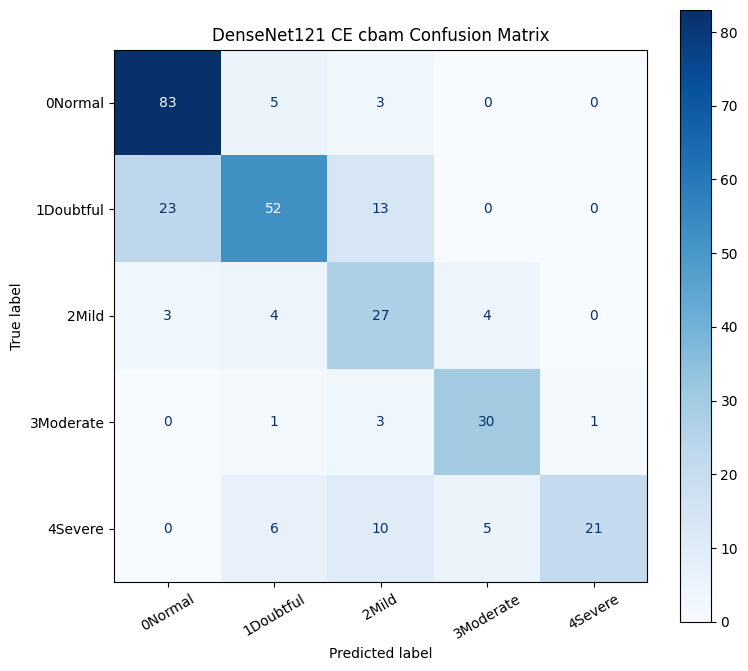

Saved figure to: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\figures\densenet121_ce_cbam_confusion_matrix.png


In [17]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 CE cbam Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_cbam_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
